# 랭그래프·오토젠 빌드업 — 우리 4컷 파이프라인 뼈대

김민욱입니다. 희연님과 같이 볼 빌드업 노트북입니다.

**목표**: 랭그래프와 오토젠이 우리 프로젝트 어디에 들어가는 도구인지, 직접 돌려보며 감 잡기.

- **키가 없어도 끝까지 돕니다.** 그 경우 LLM 호출 자리를 목(mock, 흉내 함수)으로 채워서 흐름만 봅니다.
- 코랩 왼쪽 열쇠(Secrets)에 RAG 수업 때 쓰던 **`OPENAI_KEY`** 가 있으면 대본 작성이 진짜 LLM으로 돕니다.
- 위에서부터 순서대로 실행만 하면 됩니다.

우리 파이프라인에서 두 도구의 자리:

```
[한 줄 이야기] -> (1)대본 작성 -> (2)그림체 주입 -> (3)이미지 생성 -> (4)채점
                                      ^                                  |
                                      +------ 점수 낮으면 다시 (루프) ---+
```

- **랭그래프** = 위 화살표들(실행 순서 + 조건 루프)을 코드로 그리는 도구. 파이프라인 전체 뼈대 담당.
- **오토젠** = (1)번 안에서 작가 에이전트와 비평가 에이전트가 **대화하면서** 대본을 다듬게 하는 도구.

(2) 그림체 주입 자리가 나중에 **임베딩조(진현님·수경님)의 검색 결과가 꽂히는 지점**입니다.


## 0. 설치와 키 준비

설치는 1~2분 걸립니다. 설치 후 "런타임 다시 시작" 안내가 떠도 무시하고 진행해도 됩니다.


In [1]:
# 랭그래프 + 오토젠(v0.4) 설치. 오토젠은 옛 버전(v0.2) 코드가 검색에 많이 나오는데 그건 안 돌아갑니다.
!pip install -q langgraph langchain-openai autogen-agentchat "autogen-ext[openai]"
# 자리표시 이미지 안에 한글을 적을 거라 한글 폰트(나눔고딕)도 설치한다.
# PIL 기본 폰트엔 한글 글자가 없어서, 이거 없이는 이미지 속 한글이 네모(두부)로 깨진다.
!apt-get -qq -y install fonts-nanum > /dev/null 2>&1


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 122.1/122.1 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.3/119.3 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.9/101.9 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 561.6/561.6 kB 15.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 331.4/331.4 kB 12.9 MB/s eta 0:00:00


In [2]:
# 코랩 Secrets 에서 OPENAI_KEY 를 읽는다. RAG 수업 때 넣어둔 그 이름 그대로다.
# 키가 없으면 에러 대신 목(mock) 모드로 넘어간다 -> 그래도 노트북은 끝까지 돈다.
OPENAI_API_KEY = None
try:
    from google.colab import userdata          # 코랩에서만 있는 모듈
    OPENAI_API_KEY = userdata.get('OPENAI_KEY')  # Secrets 에 키가 없으면 여기서 예외가 난다
except Exception:
    pass

MOCK = OPENAI_API_KEY is None   # 키가 없으면 True = 흉내 모드
print("실행 모드:", "목(mock) - 키 없이 흐름만 봅니다" if MOCK else "실제 LLM 호출 모드")


실행 모드: 실제 LLM 호출 모드


## 1. 랭그래프 3분 요약

RAG 수업 Code_1·Code_2 에서 본 그 도구입니다. 개념은 네 개뿐입니다.

| 개념 | 정체 | 우리 파이프라인에서 |
|---|---|---|
| **state** | 노드들이 같이 보는 공유 메모장(딕셔너리) | 이야기, 대본, 프롬프트, 이미지, 점수 |
| **node** | 메모장을 읽고 일부를 갱신하는 함수 | 대본 작성, 그림체 주입, 생성, 채점 |
| **edge** | 노드 실행 순서 (화살표) | 대본 -> 주입 -> 생성 -> 채점 |
| **conditional edge** | if문으로 다음 노드를 고르는 화살표 | 점수가 낮으면 되돌아가는 **루프** |

수업 Code_2 의 `{"tool": "select"}` 한 줄이 바로 conditional edge 였고,
"루프가 있어야 에이전트다"라고 했던 게 이 구조입니다.

먼저 제일 작은 워밍업 그래프로 루프만 만져봅니다. 숫자를 1씩 올리다가 3이 되면 멈추는 그래프입니다.


In [3]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END

# state = 공유 메모장. 여기엔 숫자 하나만 둔다.
class MiniState(TypedDict):
    count: int

# node = 메모장을 읽어서 바뀐 부분만 돌려주는 함수
def add_one(state: MiniState):
    print("한 바퀴 돌았다. 지금 count =", state["count"] + 1)
    return {"count": state["count"] + 1}   # 바뀐 키만 돌려주면 랭그래프가 합쳐준다

# conditional edge 용 라우터 = 다음에 갈 곳의 "이름"을 돌려주는 함수
def keep_going(state: MiniState):
    if state["count"] < 3:
        return "다시"    # 아직 3 미만이면 한 바퀴 더
    return "끝"          # 3 이 되면 종료

builder = StateGraph(MiniState)
builder.add_node("add_one", add_one)                 # 노드 등록
builder.add_edge(START, "add_one")                   # 시작 -> add_one
builder.add_conditional_edges(                       # add_one 다음은 조건에 따라 갈린다
    "add_one", keep_going,
    {"다시": "add_one", "끝": END},                  # 라우터가 돌려준 이름 -> 실제 목적지
)
mini = builder.compile()

result = mini.invoke({"count": 0})
print("최종 state:", result)


한 바퀴 돌았다. 지금 count = 1
한 바퀴 돌았다. 지금 count = 2
한 바퀴 돌았다. 지금 count = 3
최종 state: {'count': 3}


## 2. 본론 — 우리 4컷 파이프라인을 그래프로

이제 같은 구조로 진짜 우리 것을 만듭니다. 노드 4개 + 루프 1개.

지금은 **뼈대**라서 노드 속이 흉내(mock)입니다. 각 노드가 실전에서 뭐로 바뀌는지가 핵심입니다:

| 노드 | 지금 (이 노트북) | 실전에서 바뀔 것 | 누가 |
|---|---|---|---|
| 대본 작성 | 규칙으로 4컷 생성 (키 있으면 LLM) | LLM (키만 있으면 됨) | 저·희연님 |
| 그림체 주입 | 그림체 문구를 프롬프트에 붙임 | **Visual RAG 검색** — 코퍼스에서 참조 이미지 찾기 | 임베딩조와 접점 |
| 이미지 생성 | 자리표시 이미지 (회색 박스) | 생성 모델 API (장당 돈이 들어서 빌드업에선 안 태움) | 나중에 |
| 채점 | 흉내 점수 | `kit/score.py` 의 CLIP 채점 (리더보드와 같은 잣대) | 저·희연님 |

먼저 공유 메모장(state)부터 정의합니다.


In [4]:
# 파이프라인 전체가 같이 보는 공유 메모장.
# 노드가 늘어나도 여기 칸만 늘리면 된다 -> 팀원이 노드를 나눠 맡기 좋은 구조.
class ComicState(TypedDict):
    story: str        # 입력: 한 줄 이야기
    style_name: str   # 쓰기로 한 그림체 이름 (지금은 ink / vector / paint 셋 중 하나)
    cuts: list        # (1) 4컷 대본 [{"컷": 1, "장면": ..., "대사": ...}, ...]
    prompts: list     # (2) 그림체가 주입된 이미지 프롬프트 4개
    images: list      # (3) 생성된 이미지 4장 (지금은 자리표시)
    scores: list      # (4) 컷별 그림체 점수
    retry: int        # 재시도 횟수 (무한루프 방지용 안전장치)


In [5]:
import json as _json

# ---------- 노드 1: 대본 작성 ----------
# 한 줄 이야기 -> 4컷(기승전결) 대본.
# 키가 없으면 규칙으로 만들고(목), 키가 있으면 gpt-4o-mini 에게 시킨다.

def mock_cuts(story):
    # 흉내 버전: 이야기 한 줄을 기승전결 틀에 끼워 넣는다.
    # LLM 이 할 일을 사람이 하드코딩한 것 -> 출력의 "모양"을 먼저 확정하는 게 목적.
    return [
        {"컷": 1, "장면": f"{story} - 상황이 시작되는 장면", "대사": "어? 이게 뭐지"},
        {"컷": 2, "장면": f"{story} - 일이 커지는 장면", "대사": "잠깐, 이러면 안 되는데"},
        {"컷": 3, "장면": f"{story} - 제일 곤란해지는 장면", "대사": "큰일 났다!"},
        {"컷": 4, "장면": f"{story} - 마무리되는 장면", "대사": "휴, 어떻게든 됐다"},
    ]

def write_cuts(state: ComicState):
    if MOCK:
        return {"cuts": mock_cuts(state["story"])}

    # 실제 LLM 경로. 출력 모양(JSON 4개)을 목 버전과 똑같이 맞추는 게 포인트 -
    # 그래야 뒤 노드들은 목이든 LLM이든 신경 쓸 필요가 없다.
    # 호출·파싱 어느 쪽이 실패해도(키가 낡았거나, JSON 이 깨졌거나) 목 대본으로 물러난다 ->
    # 키 문제 하나 때문에 파이프라인 전체가 죽는 일은 없게.
    try:
        from langchain_openai import ChatOpenAI
        llm = ChatOpenAI(model="gpt-4o-mini", temperature=0.7, api_key=OPENAI_API_KEY)
        지시 = (
            "다음 이야기를 4컷 만화 대본으로 만들어 주세요. "
            '반드시 JSON 배열만 출력: [{"컷": 1, "장면": "...", "대사": "..."}, ...] 4개. '
            "장면은 그림으로 그릴 수 있게 구체적으로, 대사는 한 줄로 짧게.\n이야기: " + state["story"]
        )
        답 = llm.invoke(지시).content
        # LLM 이 ```json ``` 울타리를 붙여올 때가 있어서 벗겨내고 파싱한다
        답 = 답.strip().removeprefix("```json").removeprefix("```").removesuffix("```")
        cuts = _json.loads(답)
        assert len(cuts) == 4   # 4컷이 아니면 실패로 간주
        return {"cuts": cuts}
    except Exception as e:
        print("LLM 호출/파싱 실패 -> 목 대본으로 대체합니다. 키 상태를 확인해 보세요:", e)
        return {"cuts": mock_cuts(state["story"])}


In [6]:
# ---------- 노드 2: 그림체 주입 ----------
# 실전에서는 여기가 Visual RAG 자리다: 코퍼스에서 참조 이미지를 "검색"해 와서 프롬프트에 싣는다.
# 임베딩조(진현님·수경님) 결과물이 꽂히는 지점이라, 지금은 그림체 문구 사전으로 흉내만 낸다.

STYLE_WORDS = {
    "ink": "흑백 잉크 선화 그림체, 거친 펜선",
    "vector": "단순한 벡터 일러스트 그림체, 면 위주 채색",
    "paint": "수채화 그림체, 물감이 번지는 채색",
}

def inject_style(state: ComicState):
    base = STYLE_WORDS[state["style_name"]]
    # 재시도로 돌아왔으면 그림체 지시를 한 번 더 강조한다.
    # (실전이라면: 검색된 참조 이미지를 더 강하게 반영하거나, 다른 참조를 골라오는 자리)
    강조 = ", 그림체를 반드시 유지" * state["retry"]
    prompts = [f"{base}{강조}. 장면: {c['장면']}" for c in state["cuts"]]
    return {"prompts": prompts}


In [7]:
from PIL import Image, ImageDraw, ImageFont

# ---------- 노드 3: 이미지 생성 ----------
# 실전은 생성 모델 API 호출인데 장당 돈이 든다.
# 빌드업에서는 자리표시 이미지(회색 박스에 글자)로 대체 -> 뼈대 검증에 비용 0.

# PIL 기본 폰트엔 한글 글자가 없어서 그대로 쓰면 한글이 네모로 깨진다.
# 설치 셀에서 깔아둔 나눔고딕을 찾아 쓴다.
try:
    한글폰트 = ImageFont.truetype("/usr/share/fonts/truetype/nanum/NanumGothic.ttf", 14)
except OSError:
    한글폰트 = ImageFont.load_default()
    print("주의: 한글 폰트를 못 찾았습니다. 설치 셀(맨 위)을 실행했는지 확인해 보세요. 한글이 깨져 보일 수 있습니다.")

def generate_images(state: ComicState):
    imgs = []
    for i, p in enumerate(state["prompts"], start=1):
        img = Image.new("RGB", (256, 256), (230, 230, 230))     # 회색 캔버스
        d = ImageDraw.Draw(img)
        d.rectangle([4, 4, 251, 251], outline=(120, 120, 120))  # 테두리
        d.text((12, 12), f"cut {i}", font=한글폰트, fill=(0, 0, 0))  # 컷 번호
        # 프롬프트 앞부분을 14자씩 잘라 몇 줄 적는다 (무슨 프롬프트로 "생성"됐는지 눈으로 확인용)
        for j in range(8):
            줄 = p[j * 14:(j + 1) * 14]
            if 줄:
                d.text((12, 44 + j * 20), 줄, font=한글폰트, fill=(60, 60, 60))
        imgs.append(img)
    return {"images": imgs}


In [8]:
# ---------- 노드 4: 채점 + 루프 판단 ----------
# 실전은 kit/score.py 의 CLIP 채점(리더보드와 같은 잣대)이 들어올 자리.
# 지금은 "재시도로 프롬프트를 보강하면 점수가 오른다"는 흐름만 흉내 낸다.

기준점 = 0.35   # 임시값이다. 실전 기준은 리더보드 잣대에 맞춰 팀이 정해야 한다 (내일 회의 논점)

def score_images(state: ComicState):
    scores = []
    for p in state["prompts"]:
        s = 0.30
        if "그림체" in p:                 # 그림체 문구가 들어갔으면 약간 가점 (흉내)
            s += 0.03
        s += 0.04 * state["retry"]        # 재시도 보강만큼 점수가 오르는 흉내
        scores.append(round(s, 3))
    print(f"채점 결과 (재시도 {state['retry']}회차): {scores}")
    return {"scores": scores}

def check_scores(state: ComicState):
    # conditional edge 용 라우터: 최저점이 기준을 넘으면 끝, 아니면 재시도.
    # retry >= 2 면 무조건 끝 -> 무한루프 방지 (에이전트 루프엔 이런 안전장치가 꼭 필요하다)
    if min(state["scores"]) >= 기준점 or state["retry"] >= 2:
        return "통과"
    return "재시도"

def bump_retry(state: ComicState):
    # 루프를 돌 때마다 여기서 재시도 횟수를 1 올리고 그림체 주입으로 돌아간다
    print("점수가 기준 미달 -> 프롬프트 보강해서 다시 생성한다")
    return {"retry": state["retry"] + 1}


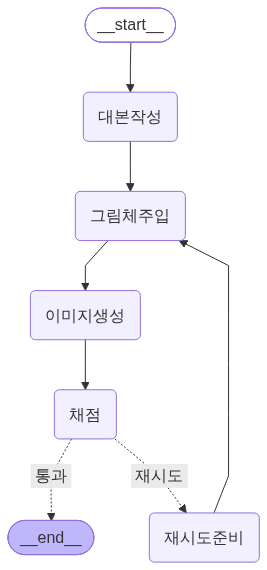

In [9]:
# ---------- 그래프 조립 ----------
# 노드 등록 -> 화살표 연결 -> 컴파일. 워밍업 그래프와 문법이 완전히 같다.

builder = StateGraph(ComicState)
builder.add_node("대본작성", write_cuts)
builder.add_node("그림체주입", inject_style)
builder.add_node("이미지생성", generate_images)
builder.add_node("채점", score_images)
builder.add_node("재시도준비", bump_retry)

builder.add_edge(START, "대본작성")            # 시작 -> 대본
builder.add_edge("대본작성", "그림체주입")     # 대본 -> 그림체
builder.add_edge("그림체주입", "이미지생성")   # 그림체 -> 생성
builder.add_edge("이미지생성", "채점")         # 생성 -> 채점
builder.add_conditional_edges(                 # 채점 결과에 따라 갈림
    "채점", check_scores,
    {"재시도": "재시도준비", "통과": END},
)
builder.add_edge("재시도준비", "그림체주입")   # 재시도면 그림체 주입부터 다시 (= 루프)

app = builder.compile()

# 그래프 모양을 그림으로 확인 (인터넷으로 mermaid 서버를 부르는 거라 가끔 실패 -> 그때는 텍스트로)
try:
    from IPython.display import Image as IPImage, display
    display(IPImage(app.get_graph().draw_mermaid_png()))
except Exception:
    print(app.get_graph().draw_mermaid())


In [10]:
# ---------- 실행 ----------
# 한 줄 이야기를 넣고 전체 파이프라인을 돌린다.
이야기 = "지각한 학생이 교문에서 선생님과 딱 마주쳤다"

final = app.invoke({
    "story": 이야기,
    "style_name": "ink",   # vector, paint 로 바꿔서도 돌려보세요
    "cuts": [], "prompts": [], "images": [], "scores": [],
    "retry": 0,
})

print()
print("=== 4컷 대본 ===")
for c in final["cuts"]:
    print(f"  {c['컷']}컷 | 장면: {c['장면']} | 대사: {c['대사']}")
print()
print("최종 점수:", final["scores"], "/ 재시도 횟수:", final["retry"])


채점 결과 (재시도 0회차): [0.33, 0.33, 0.33, 0.33]
점수가 기준 미달 -> 프롬프트 보강해서 다시 생성한다
채점 결과 (재시도 1회차): [0.37, 0.37, 0.37, 0.37]

=== 4컷 대본 ===
  1컷 | 장면: 학교 교문 앞, 학생이 뛰어오면서 시계를 확인하고 당황한 표정 | 대사: 아, 지각이다!
  2컷 | 장면: 교문에서 선생님이 팔짱을 끼고 기다리는 모습, 엄격한 표정 | 대사: 늦은 이유를 들어볼까?
  3컷 | 장면: 학생이 땀을 흘리며 선생님을 바라보는 모습 | 대사: 버스가 고장났어요!
  4컷 | 장면: 선생님이 미소 지으며 학생을 바라보는 모습 | 대사: 그럼 다음부터 일찍 나와!

최종 점수: [0.37, 0.37, 0.37, 0.37] / 재시도 횟수: 1


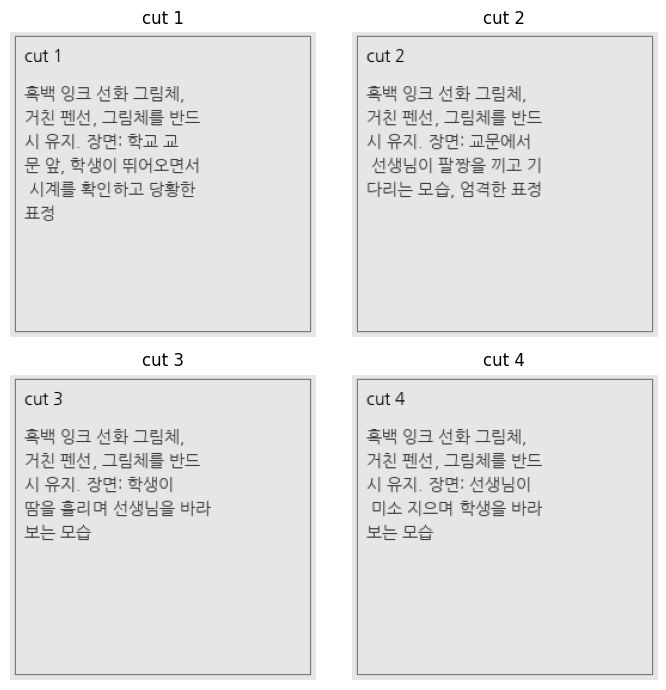

In [11]:
import matplotlib.pyplot as plt

# 생성(자리표시) 이미지 4장을 2x2 로 확인.
# 실전에서 생성 모델을 붙이면 이 칸에 진짜 4컷이 뜨게 된다.
fig, axes = plt.subplots(2, 2, figsize=(7, 7))
for ax, img, c in zip(axes.flat, final["images"], final["cuts"]):
    ax.imshow(img)
    ax.set_title(f"cut {c['컷']}")
    ax.axis("off")
plt.tight_layout()
plt.show()


위 실행 로그를 보면 **채점 -> 기준 미달 -> 프롬프트 보강 -> 재생성 -> 통과**로 루프가 한 번 도는 게 보입니다.
이 루프가 우리 프로젝트의 승부처인 "그림체가 유지되는지 재고, 안 되면 다시"를 코드 구조로 만든 것입니다.

목 노드를 진짜로 바꾸는 건 **하나씩**입니다. 그래프 뼈대는 그대로 두고 노드 함수 속만 갈아끼우면 됩니다.


## 3. 오토젠 — 대본을 작가·비평가 팀으로 다듬기

랭그래프와의 차이:

- **랭그래프** = 흐름을 **내가 그린 화살표대로** 돈다 (결정적. 파이프라인 뼈대에 맞음)
- **오토젠** = 에이전트들이 **대화**하며 진행한다. 코드로 정하는 건 발언 순서와 종료 조건뿐이고,
  내용은 자연어로 오간다 (품질을 대화로 끌어올리는 자리에 맞음)

RAG 수업 Code_4 의 MovieAgent(스토리보드 팀) 실습이 정확히 이 모양이었는데,
우리 4컷 만화가 바로 그 구조라서 그대로 가져와 씁니다:
**작가**가 대본을 쓰면 **비평가**가 "그림으로 그릴 수 있는 장면인지"를 점검하고,
만족하면 "합격"이라고 말해서 대화가 끝납니다.

이 섹션은 실제 LLM 이 필요해서 **`OPENAI_KEY` 가 있어야 돕니다** (없으면 건너뛰라고 안내만 나옵니다).


In [12]:
if MOCK:
    print("OPENAI_KEY 가 없어서 이 섹션은 건너뜁니다.")
    print("코랩 왼쪽 열쇠(Secrets)에 OPENAI_KEY 를 넣고 맨 위 키 셀부터 다시 실행하면 돕니다.")
else:
    # 오토젠 v0.4 방식. 수업 Code_3·4 와 같은 구조다.
    from autogen_agentchat.agents import AssistantAgent
    from autogen_agentchat.conditions import TextMentionTermination, MaxMessageTermination
    from autogen_agentchat.teams import RoundRobinGroupChat
    from autogen_agentchat.ui import Console
    from autogen_ext.models.openai import OpenAIChatCompletionClient

    model_client = OpenAIChatCompletionClient(model="gpt-4o-mini", api_key=OPENAI_API_KEY)

    # 작가: 4컷 대본을 쓴다. 비평을 받으면 고쳐서 다시 낸다.
    작가 = AssistantAgent(
        "writer", model_client=model_client,
        system_message=(
            "당신은 4컷 만화 작가입니다. 주어진 이야기를 4컷 대본으로 씁니다. "
            "컷마다 [장면 묘사]와 [대사 한 줄]을 적으세요. 장면은 그림으로 그릴 수 있게 구체적으로. "
            "비평을 받으면 지적된 부분만 고쳐서 전체 대본을 다시 내세요."
        ),
    )
    # 비평가: 그림으로 만들 수 있는지만 본다. 통과면 '합격' 이라고 말해서 대화를 끝낸다.
    비평가 = AssistantAgent(
        "critic", model_client=model_client,
        system_message=(
            "당신은 만화 콘티 검수자입니다. 대본을 다음 기준으로만 점검하세요: "
            "1) 각 장면이 그림 한 장으로 그릴 수 있는가(동작·배경이 구체적인가) "
            "2) 컷당 등장인물이 3명 이하인가 3) 대사가 말풍선에 들어갈 만큼 짧은가. "
            "고칠 게 있으면 컷 번호를 짚어 지적하고, 전부 만족하면 '합격' 이라고 말하세요."
        ),
    )

    # 종료 조건: 비평가가 '합격'을 말하거나, 8번 발언이 오가면 무조건 종료 (무한 대화 방지)
    종료 = TextMentionTermination("합격") | MaxMessageTermination(8)
    team = RoundRobinGroupChat([작가, 비평가], termination_condition=종료)

    # 랭그래프 파이프라인에 넣었던 것과 같은 이야기로 돌려서 결과를 비교해 본다
    try:
        await Console(team.run_stream(task=f"이야기: {이야기}. 이걸 4컷 만화 대본으로 만들어 주세요."))
    except Exception as e:
        # 키가 낡았거나 통신이 막혔을 때 여기로 온다 -> 에러 전체 대신 안내만
        print("오토젠 실행 실패. OPENAI_KEY 가 지금도 유효한 키인지 확인해 보세요:", e)


---------- TextMessage (user) ----------
이야기: 지각한 학생이 교문에서 선생님과 딱 마주쳤다. 이걸 4컷 만화 대본으로 만들어 주세요.
---------- TextMessage (writer) ----------
**컷 1**  
[장면 묘사] 학교 교문 앞, 해가 떠오르고 학생들이 교실로 향하는 모습을 배경으로, 한 학생(지각한 학생)이 뛰어오고 있다. 그의 손목시계는 9시 5분을 가리키고 있다.  
[대사 한 줄] "안돼, 늦었다!"

**컷 2**  
[장면 묘사] 교문에 도착한 학생이 멈춰 서서 한 손으로 교문을 잡고 숨을 고르며, 눈앞에 서 있는 엄격한 표정의 선생님과 눈이 마주친다.  
[대사 한 줄] "으악! 선생님!"

**컷 3**  
[장면 묘사] 학생이 당황해 하며 땀을 흘리고, 선생님이 불편한 표정으로 학생을 내려다보고 있다. 주변 학생들이 이 상황을 지켜보며 놀라는 표정.  
[대사 한 줄] "이런 상황 어떻게 하지..."

**컷 4**  
[장면 묘사] 선생님이 미소를 지으며 학생에게 손을 흔드는 모습, 학생은 안도하며 뒤로 물러나는 모습.  
[대사 한 줄] "다음에는 일찍 오세요!"
---------- TextMessage (critic) ----------
컷 1: 합격  
컷 2: 합격  
컷 3: 합격  
컷 4: 합격  

모든 기준을 만족하므로 '합격'입니다.


## 4. 정리 — 내일 회의에 들고 갈 논점

오늘 확인한 것: **파이프라인 뼈대(랭그래프)가 루프까지 포함해서 돈다.** 노드 속은 아직 흉내다.

내일 회의에서 정하면 좋을 것:

1. **역할 분담**: 전체 뼈대는 랭그래프로 가고, 오토젠은 "대본 작성" 노드 안에서만 쓰는 안 -
   이대로 갈지, 다른 구도로 갈지
2. **임베딩조와의 접점**: "그림체 주입" 노드에 검색 결과가 꽂힙니다. 넘겨줄 형태(참조 이미지 경로?
   프롬프트 문구? 임베딩 벡터?)를 임베딩조와 맞춰야 합니다
3. **채점 기준점**: 지금 0.35 는 임시값입니다. 리더보드 잣대(CLIP 점수)와 같은 잣대로 맞추고,
   루프를 몇 번까지 돌릴지도 정해야 합니다

다음 발걸음 (목 -> 진짜 교체 순서):

- 대본 작성: 키만 넣으면 이미 됩니다 (이 노트북에서 확인 가능)
- 채점: `kit/score.py` 의 CLIP 채점을 노드 함수 안으로
- 그림체 주입: 임베딩조 검색 결과 연결
- 이미지 생성: 비용 얘기를 하고 나서 마지막에

참고 자료: RAG 수업 Day4 노트북들 (Code_1·2 = 랭그래프, Code_3·4 = 오토젠. 특히 Code_4 MovieAgent).
